In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Metadata.paths import LIW
from Metadata.paths import TRIGGERED_EVENT_LIST


# 340 String MC

In [16]:

electron_weights = pd.read_csv(LIW["String340MC"]["Electron"])
triggered_electrons = pd.read_csv(TRIGGERED_EVENT_LIST["String340MC"]["102_string"]["Electron"])


In [17]:

electron_neutrino = electron_weights.loc[
    electron_weights["initialType"] > 0
].copy()

electron_antineutrino = electron_weights.loc[
    electron_weights["initialType"] < 0
].copy()

electron_antineutrino["final_weight"] = electron_antineutrino["oneweight_x100"] / len(electron_antineutrino)
electron_neutrino["final_weight"] = electron_neutrino["oneweight_x100"] / len(electron_neutrino)


common_columns = ["EventID", "SubEventID", "RunID", "SubrunID"]

electron_neutrino = electron_neutrino.merge(
    triggered_electrons,
    on=common_columns,
    how="inner",
)

electron_antineutrino = electron_antineutrino.merge(
    triggered_electrons,
    on=common_columns,
    how="inner",
)



In [18]:
len(electron_antineutrino) + len(electron_neutrino) == len(triggered_electrons)

True

## Effective area and MC uncertainty

Triggered electron neutrino and antineutrino samples are combined and binned in true energy.

$$
A_{\mathrm{eff}}(E) = \frac{\sum_{i \in E\;\mathrm{bin}} w_i}{\Delta E\,\Delta\Omega}
$$

$$
\sigma_{A_{\mathrm{eff}}}(E) = \frac{\sqrt{\sum_{i \in E\;\mathrm{bin}} w_i^2}}{\Delta E\,\Delta\Omega}
$$

Here $w_i = \texttt{final\_weight}_i$ and $\Delta\Omega = 4\pi$ for the all-sky average.


electron neutrino
  Median relative uncertainty: 0.06589665120430417
  Maximum relative uncertainty: 0.21354644851102553
electron antineutrino
  Median relative uncertainty: 0.07007945031817973
  Maximum relative uncertainty: 0.21019553408748745


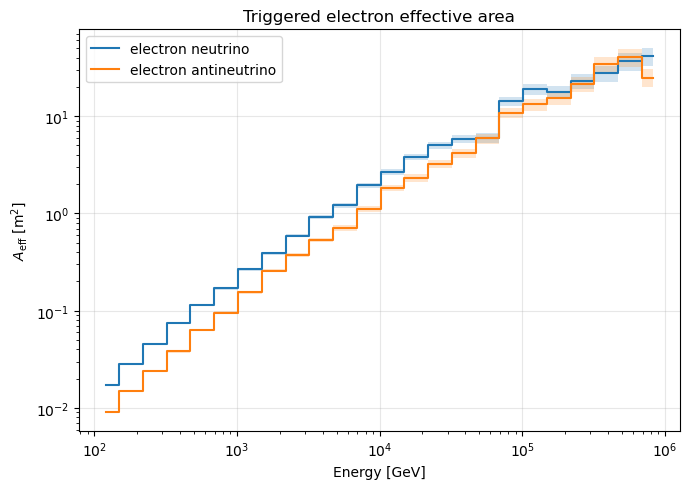

In [19]:
samples = {
    "electron neutrino": electron_neutrino,
    "electron antineutrino": electron_antineutrino,
}

all_energy = pd.concat([df["energy"] for df in samples.values()], ignore_index=True)
all_energy = all_energy[np.isfinite(all_energy) & (all_energy > 0)]

energy_bins = np.logspace(np.log10(all_energy.min()), np.log10(all_energy.max()), 25)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
delta_energy = np.diff(energy_bins)
delta_omega = 4 * np.pi

plt.figure(figsize=(7, 5))

for label, df in samples.items():
    valid = (
        np.isfinite(df["energy"])
        & np.isfinite(df["final_weight"])
        & (df["energy"] > 0)
        & (df["final_weight"] > 0)
    )
    energy = df.loc[valid, "energy"].to_numpy()
    weight = df.loc[valid, "final_weight"].to_numpy()

    sum_weight, _ = np.histogram(energy, bins=energy_bins, weights=weight)
    sum_weight2, _ = np.histogram(energy, bins=energy_bins, weights=weight**2)

    effective_area_cm2 = sum_weight / (delta_energy * delta_omega)
    effective_area_unc_cm2 = np.sqrt(sum_weight2) / (delta_energy * delta_omega)

    effective_area_m2 = effective_area_cm2 / 1e4
    effective_area_unc_m2 = effective_area_unc_cm2 / 1e4

    positive = np.isfinite(effective_area_m2) & (effective_area_m2 > 0)
    lower = np.maximum(effective_area_m2 - effective_area_unc_m2, np.nextafter(0, 1))
    upper = effective_area_m2 + effective_area_unc_m2

    plt.step(energy_centers[positive], effective_area_m2[positive], where="mid", label=label)
    plt.fill_between(
        energy_centers[positive],
        lower[positive],
        upper[positive],
        step="mid",
        alpha=0.2,
    )

    relative_uncertainty = np.full_like(effective_area_m2, np.nan, dtype=float)
    relative_uncertainty[positive] = effective_area_unc_m2[positive] / effective_area_m2[positive]
    print(label)
    print("  Median relative uncertainty:", np.nanmedian(relative_uncertainty))
    print("  Maximum relative uncertainty:", np.nanmax(relative_uncertainty))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Triggered electron effective area")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
